<a href="https://colab.research.google.com/github/JiyadR/BigData26_A_2411533003_Jiyad-Rifqi-Pasaribu/blob/main/Praktikum01/BD_A_P01_2411533003_Jiyad_Rifqi_Pasaribu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **J-1. Verifikasi lingkungan kerja**

Cell ini digunakan untuk **memverifikasi lingkungan kerja Google Colab** sebelum praktikum dimulai. Kode menampilkan versi Python, sistem operasi, jumlah core CPU, versi beberapa library utama, serta mengecek kapasitas RAM, disk, dan versi Java yang dibutuhkan untuk menjalankan PySpark.

In [25]:
import sys, platform, multiprocessing

print("Python  :", sys.version.split()[0])
print("OS      :", platform.platform())
print("CPU core:", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")


!free -h              # kapasitas dan sisa RAM
!df -h /content       # kapasitas dan sisa disk runtime
!java -version        # dibutuhkan PySpark pada langkah K-8

Python  : 3.13.15
OS      : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core: 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0
               total        used        free      shared  buff/cache   available
Mem:            12Gi       2.9Gi       6.2Gi       2.8Mi       3.9Gi       9.8Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   22G   87G  21% /
[0.003s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.003s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


### **J-2. Menghubungkan Google Drive dan menyiapkan struktur folder**

Google Drive terlebih dahulu dihubungkan ke Google Colab agar hasil praktikum dapat disimpan dan tetap tersedia meskipun runtime berakhir. Setelah itu, dibuat folder kerja lokal dan folder penyimpanan di Google Drive, lalu isi folder tujuan ditampilkan untuk memastikan direktori sudah siap digunakan.

In [26]:
from google.colab import drive
drive.mount("/content/drive")
import os
DIR_KERJA  = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['agregasi_per_jam.csv', 'agregasi_per_jam.parquet', 'pengukuran_kinerja.csv', 'distribusi_per_jam.png']


### **J-3. Menyiapkanalat ukur waktu dan memori**

Untuk mengukur performa pengolahan data nantinya, kode ini menyiapkan alat pencatat waktu dan penggunaan memori proses Python. Fungsi ukur() kemudian dapat menjalankan suatu proses sekaligus mencatat durasi eksekusi dan perubahan RSS, lalu menyimpan hasilnya ke dalam catatan agar strategi pengolahan data bisa dibandingkan.



In [27]:
import time, os, psutil


proses = psutil.Process(os.getpid())
catatan = []        # menyimpan hasil pengukuran untuk dibandingkan nanti


def rss_mb():
    return proses.memory_info().rss / 1024**2


def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil  = fungsi()
    detik  = time.perf_counter() - t0
    delta  = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                    "delta_rss_mb": round(delta, 1)})

    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil

### **J-4. Mengunduh dataset daninspeksi awal**

Dataset NYC TLC terlebih dahulu diunduh secara terprogram dan disimpan pada folder kerja yang telah disiapkan sebelumnya. Setelah file tersedia, metadata Parquet diperiksa tanpa memuat seluruh data ke memori untuk mengetahui ukuran file, jumlah baris dan kolom, jumlah row group, serta nama-nama kolom yang tersedia.

In [28]:
import urllib.request


URL  = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
        "yellow_tripdata_2023-01.parquet")
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH):
    ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

import pyarrow.parquet as pq


meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris  :", f"{meta.num_rows:,}")
print("Jumlah kolom  :", meta.num_columns)
print("Row group     :", meta.num_row_groups)
print("Nama kolom    :", pq.ParquetFile(PATH).schema.names)

Ukuran file: 45.5 MB
Jumlah baris  : 3,066,766
Jumlah kolom  : 19
Row group     : 1
Nama kolom    : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


### **J-5. Memuat data dan mengukur biaya memorinya**

Bagian ini membandingkan dua cara membaca dataset, yaitu memuat seluruh kolom terlebih dahulu lalu hanya mengambil kolom yang benar-benar diperlukan untuk praktikum. Waktu proses dan penggunaan memori dari keduanya dicatat dengan ukur(), kemudian DataFrame hasil pembacaan kolom terpilih ditampilkan beberapa barisnya untuk memastikan data berhasil dimuat.

In [29]:
import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori :", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
df.head()


[baca semua kolom] 2.75 s | RSS +476.8 MB
Dimensi: (3066766, 19)
Memori : 565.6 MB
[baca kolom terpilih] 0.56 s | RSS +197.4 MB
Dimensi: (3066766, 8)
Memori : 187.2 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,2,9.3,0.00,14.30
1,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1,7.9,4.00,16.90
2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1,14.9,15.00,34.90
3,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1,12.1,0.00,20.85
4,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1,11.4,3.28,19.68


Setelah DataFrame dimuat, informasi detail mengenai struktur dan penggunaan memorinya diperiksa melalui df.info() serta df.memory_usage(). Hasilnya menunjukkan tipe data setiap kolom sekaligus membantu mengidentifikasi kolom mana yang menggunakan memori paling besar sebelum dilakukan optimasi tipe data.

In [30]:
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2    # MB per kolom

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB


,0
tpep_pickup_datetime,23.397568
payment_type,23.397568
tpep_dropoff_datetime,23.397568
passenger_count,23.397568
trip_distance,23.397568
tip_amount,23.397568
fare_amount,23.397568
total_amount,23.397568
Index,0.000126


Setelah mengetahui penggunaan memori awal, tipe data pada beberapa kolom diperkecil agar DataFrame menjadi lebih hemat memori. passenger_count dan kolom numerik lainnya di-downcast, sedangkan payment_type diubah menjadi tipe category, kemudian penggunaan memori sebelum dan sesudah optimasi dibandingkan untuk melihat persentase penghematannya.

In [31]:
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"]    = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB  (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

187.2 MB -> 119.9 MB  (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


### **J-6. Pemeriksaankualitas data danpembersihan(veracity)**

Data kemudian diperiksa kualitasnya dengan menghitung durasi perjalanan dalam menit dari waktu berangkat dan waktu tiba. Setelah itu, ditampilkan statistik dasar, jumlah nilai kosong, serta beberapa jenis anomali seperti jarak atau durasi yang tidak valid, durasi lebih dari 180 menit, dan total_amount yang tidak memenuhi kriteria, lengkap dengan jumlah serta persentasenya.

In [32]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] -
df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0"           : (df["trip_distance"] <= 0).sum(),
    "durasi <= 0"          : (df["durasi_menit"]  <= 0).sum(),
    "durasi > 180 menit"   : (df["durasi_menit"]  > 180).sum(),
    "total_amount <= 0"    : (df["total_amount"]  <= 0).sum(),
}
for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)


Berdasarkan kriteria yang ditetapkan, data kemudian disaring untuk mempertahankan perjalanan dengan jarak, durasi, dan total_amount yang dianggap layak dianalisis. Hasil penyaringan disimpan sebagai bersih, lalu jumlah baris sebelum dan sesudah pembersihan dibandingkan untuk mengetahui berapa banyak data yang dibuang.

In [33]:
layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)
bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris  (dibuang {len(df)-len(bersih):,})")

3,066,766 baris -> 2,986,911 baris  (dibuang 79,855)


### **Studi Kasus**



Kode ini menambahkan informasi nama hari, menandai apakah perjalanan terjadi pada akhir pekan (Sabtu/Minggu), dan menghitung tarif rata-rata per menit dari total biaya perjalanan. Hasilnya digunakan untuk mempermudah analisis perbedaan perjalanan berdasarkan hari dan biaya per menit.

In [34]:
# 1. Tambahkan dimensi hari
bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()

# True = Sabtu/Minggu, False = hari kerja
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5

# Tarif per menit sesuai instruksi studi kasus
bersih["tarif_per_menit"] = (
    bersih["total_amount"] / bersih["durasi_menit"]
).round(3)

Kode ini menyusun ringkasan perjalanan berdasarkan jam dan jenis hari, yaitu akhir pekan atau hari kerja. Dari pengelompokan tersebut, dihitung jumlah perjalanan, rata-rata durasi, rata-rata tarif, serta rata-rata tarif per menit sehingga pola biaya dan perjalanan pada setiap jam dapat dibandingkan dengan lebih jelas.

In [35]:
ringkas = (
    bersih
    .assign(jam=bersih["tpep_pickup_datetime"].dt.hour)
    .groupby(["akhir_pekan", "jam"])
    .agg(
        jumlah_perjalanan=("total_amount", "size"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif=("total_amount", "mean"),
        rata_tarif_per_menit=("tarif_per_menit", "mean")
    )
    .round(2)
    .reset_index()
)

print(" RINGKASAN AKHIR PEKAN VS HARI KERJA ")
display(ringkas)

 RINGKASAN AKHIR PEKAN VS HARI KERJA 


,akhir_pekan,jam,jumlah_perjalanan,rata_durasi,rata_tarif,rata_tarif_per_menit
0,False,0,35351,14.10,33.509998,2.57
1,False,1,17516,13.04,31.080000,2.66
2,False,2,9452,12.23,27.690001,2.63
3,False,3,6238,12.87,30.940001,2.72
4,False,4,6192,14.79,37.990002,2.81
5,False,5,12462,14.63,36.270000,2.82
6,False,6,35728,14.57,29.400000,2.33
7,False,7,74157,14.66,25.959999,2.07
8,False,8,98431,14.82,24.809999,1.90
9,False,9,103263,15.03,25.639999,1.90


Kode ini mengelompokkan seluruh perjalanan berdasarkan jam keberangkatan, lalu mencari waktu dengan jumlah perjalanan paling banyak dan paling sedikit. Dengan begitu, kita bisa mengetahui kapan permintaan perjalanan berada pada titik tertinggi dan terendah dalam satu hari.

In [36]:
per_jam = (
    bersih
    .assign(jam=bersih["tpep_pickup_datetime"].dt.hour)
    .groupby("jam")
    .agg(
        jumlah_perjalanan=("total_amount", "size"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif=("total_amount", "mean"),
        rata_tarif_per_menit=("tarif_per_menit", "mean")
    )
    .round(2)
    .reset_index()
)

jam_tertinggi = per_jam.loc[
    per_jam["jumlah_perjalanan"].idxmax()
]

jam_terendah = per_jam.loc[
    per_jam["jumlah_perjalanan"].idxmin()
]

print("\n PERTANYAAN 1 ")
print(
    f"Permintaan tertinggi: jam {int(jam_tertinggi['jam']):02d}.00 "
    f"dengan {int(jam_tertinggi['jumlah_perjalanan']):,} perjalanan."
)

print(
    f"Permintaan terendah: jam {int(jam_terendah['jam']):02d}.00 "
    f"dengan {int(jam_terendah['jumlah_perjalanan']):,} perjalanan."
)


 PERTANYAAN 1 
Permintaan tertinggi: jam 18.00 dengan 210,858 perjalanan.
Permintaan terendah: jam 04.00 dengan 16,618 perjalanan.


Kode ini memisahkan data menjadi hari kerja dan akhir pekan, kemudian mencari jam ketika jumlah perjalanan paling tinggi pada masing-masing kelompok. Hasilnya menunjukkan waktu puncak permintaan pada hari kerja dibandingkan dengan akhir pekan, sehingga pola perjalanan keduanya dapat terlihat dengan lebih mudah.

In [37]:
weekday = ringkas[ringkas["akhir_pekan"] == False].copy()
weekend = ringkas[ringkas["akhir_pekan"] == True].copy()

# Jam dengan permintaan tertinggi untuk masing-masing kelompok
puncak_weekday = weekday.loc[
    weekday["jumlah_perjalanan"].idxmax()
]

puncak_weekend = weekend.loc[
    weekend["jumlah_perjalanan"].idxmax()
]

print("\n PERTANYAAN 2 ")
print(
    f"Hari kerja mencapai puncak pada jam {int(puncak_weekday['jam']):02d}.00 "
    f"dengan {int(puncak_weekday['jumlah_perjalanan']):,} perjalanan."
)

print(
    f"Akhir pekan mencapai puncak pada jam {int(puncak_weekend['jam']):02d}.00 "
    f"dengan {int(puncak_weekend['jumlah_perjalanan']):,} perjalanan."
)


 PERTANYAAN 2 
Hari kerja mencapai puncak pada jam 18.00 dengan 159,457 perjalanan.
Akhir pekan mencapai puncak pada jam 16.00 dengan 54,057 perjalanan.


Kode ini membandingkan jam sibuk dengan jam-jam lainnya untuk melihat apakah perjalanan pada waktu paling ramai memiliki durasi lebih singkat sekaligus tarif per menit yang lebih tinggi. Di bagian akhir, program menentukan apakah klaim tersebut benar, hanya sebagian benar, atau tidak terbukti berdasarkan hasil perbandingan.

In [38]:
# Jam sibuk didefinisikan sebagai jam dengan jumlah perjalanan tertinggi
jam_sibuk = int(jam_tertinggi["jam"])

sibuk = per_jam[per_jam["jam"] == jam_sibuk].iloc[0]
jam_lain = per_jam[per_jam["jam"] != jam_sibuk]

perbandingan_lain = {
    "rata_durasi": jam_lain["rata_durasi"].mean(),
    "rata_tarif_per_menit": jam_lain["rata_tarif_per_menit"].mean()
}

durasi_sibuk = sibuk["rata_durasi"]
tarif_menit_sibuk = sibuk["rata_tarif_per_menit"]

durasi_lain = perbandingan_lain["rata_durasi"]
tarif_menit_lain = perbandingan_lain["rata_tarif_per_menit"]

lebih_pendek = durasi_sibuk < durasi_lain
lebih_menguntungkan = tarif_menit_sibuk > tarif_menit_lain

print("\n PERTANYAAN 3 ")
print(
    f"Jam sibuk = {jam_sibuk:02d}.00 | "
    f"durasi rata-rata {durasi_sibuk:.2f} menit | "
    f"tarif/menit {tarif_menit_sibuk:.3f}"
)

print(
    f"Jam lain = durasi rata-rata {durasi_lain:.2f} menit | "
    f"tarif/menit {tarif_menit_lain:.3f}"
)

if lebih_pendek and lebih_menguntungkan:
    print("Kesimpulan: BENAR, jam sibuk lebih pendek dan lebih menguntungkan per menit.")
elif lebih_pendek:
    print("Kesimpulan: jam sibuk lebih pendek, tetapi tidak lebih menguntungkan per menit.")
elif lebih_menguntungkan:
    print("Kesimpulan: jam sibuk lebih menguntungkan per menit, tetapi tidak lebih pendek.")
else:
    print("Kesimpulan: klaim tersebut TIDAK terbukti.")


 PERTANYAAN 3 
Jam sibuk = 18.00 | durasi rata-rata 14.24 menit | tarif/menit 2.150
Jam lain = durasi rata-rata 14.23 menit | tarif/menit 2.211
Kesimpulan: klaim tersebut TIDAK terbukti.


Kode ini membuat tabel rangkuman akhir yang berisi jawaban dari setiap pertanyaan beserta nilai hasil perhitungannya. Dengan tabel tersebut, seluruh hasil analisis seperti jam dengan permintaan tertinggi, puncak hari kerja dan akhir pekan, serta perbandingan durasi dan tarif per menit dapat dilihat secara rapi dan mudah dibaca.

In [39]:
tabel_jawaban = pd.DataFrame({
    "Pertanyaan": [
        "1. Permintaan tertinggi",
        "1. Permintaan terendah",
        "2. Puncak hari kerja",
        "2. Puncak akhir pekan",
        "3. Jam sibuk: durasi rata-rata",
        "3. Jam sibuk: tarif/menit",
        "3. Jam lain: durasi rata-rata",
        "3. Jam lain: tarif/menit"
    ],
    "Nilai": [
        f"{int(jam_tertinggi['jam']):02d}.00 ({int(jam_tertinggi['jumlah_perjalanan']):,} perjalanan)",
        f"{int(jam_terendah['jam']):02d}.00 ({int(jam_terendah['jumlah_perjalanan']):,} perjalanan)",
        f"{int(puncak_weekday['jam']):02d}.00 ({int(puncak_weekday['jumlah_perjalanan']):,})",
        f"{int(puncak_weekend['jam']):02d}.00 ({int(puncak_weekend['jumlah_perjalanan']):,})",
        f"{durasi_sibuk:.2f} menit",
        f"{tarif_menit_sibuk:.3f}",
        f"{durasi_lain:.2f} menit",
        f"{tarif_menit_lain:.3f}"
    ]
})

display(tabel_jawaban)

,Pertanyaan,Nilai
0,1. Permintaan tertinggi,"18.00 (210,858 perjalanan)"
1,1. Permintaan terendah,"04.00 (16,618 perjalanan)"
2,2. Puncak hari kerja,"18.00 (159,457)"
3,2. Puncak akhir pekan,"16.00 (54,057)"
4,3. Jam sibuk: durasi rata-rata,14.24 menit
5,3. Jam sibuk: tarif/menit,2.150
6,3. Jam lain: durasi rata-rata,14.23 menit
7,3. Jam lain: tarif/menit,2.211


Kode ini membuat grafik garis untuk memperlihatkan perubahan jumlah perjalanan setiap jam, sekaligus membandingkan pola antara semua hari, hari kerja, dan akhir pekan. Dengan visualisasi ini, jam-jam dengan permintaan tinggi maupun rendah dapat terlihat lebih jelas sehingga perbedaan pola perjalanan lebih mudah dianalisis.

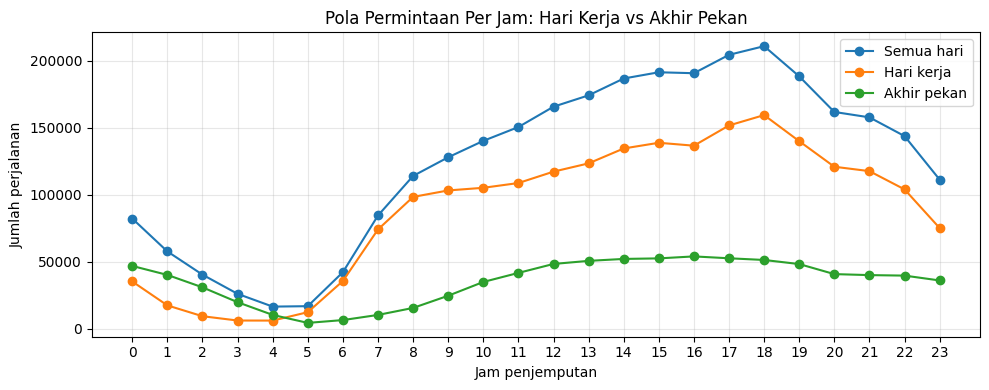

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.plot(
    per_jam["jam"],
    per_jam["jumlah_perjalanan"],
    marker="o",
    label="Semua hari"
)

plt.plot(
    weekday["jam"],
    weekday["jumlah_perjalanan"],
    marker="o",
    label="Hari kerja"
)

plt.plot(
    weekend["jam"],
    weekend["jumlah_perjalanan"],
    marker="o",
    label="Akhir pekan"
)

plt.xlabel("Jam penjemputan")
plt.ylabel("Jumlah perjalanan")
plt.title("Pola Permintaan Per Jam: Hari Kerja vs Akhir Pekan")
plt.xticks(range(24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Kode ini menghasilkan grafik garis yang menunjukkan rata-rata durasi perjalanan pada setiap jam penjemputan. Grafik tersebut membantu melihat jam-jam ketika perjalanan cenderung lebih lama atau lebih singkat, sehingga pola waktu tempuh sepanjang hari dapat dipahami dengan lebih mudah.

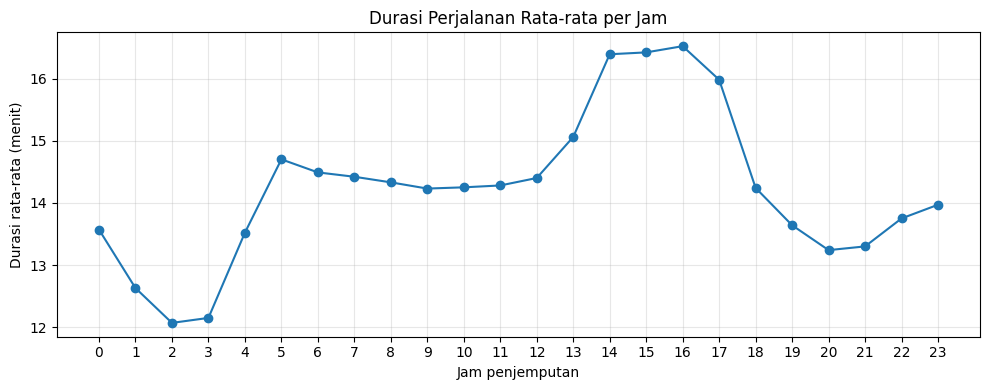

In [41]:
plt.figure(figsize=(10, 4))

plt.plot(
    per_jam["jam"],
    per_jam["rata_durasi"],
    marker="o",
    label="Rata-rata durasi (menit)"
)

plt.xlabel("Jam penjemputan")
plt.ylabel("Durasi rata-rata (menit)")
plt.title("Durasi Perjalanan Rata-rata per Jam")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **J-7. Memproses file lebih besar dari memori dengan chunking**

Data yang sudah dibersihkan kemudian ditulis ke dalam format CSV untuk mensimulasikan kondisi file berukuran lebih besar dibandingkan Parquet. Selanjutnya, proses chunking membaca CSV secara bertahap sebanyak 500.000 baris per potongan, lalu menghitung jumlah perjalanan, total total_amount, dan agregasi berdasarkan jam tanpa memuat seluruh file ke memori sekaligus.

In [42]:
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV)  / 1024**2, 1), "MB")


def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai  = 0.0
    per_jam      = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai  += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[tulis CSV] 47.50 s | RSS +5.0 MB
Parquet: 45.5 MB
CSV    : 282.5 MB
[agregasi chunking] 5.62 s | RSS +12.3 MB
2,986,911 baris | rata-rata total_amount = 27.33


### **J-8. Pendekatan terdistribusi: PySparklocal mode**

PySpark kemudian disiapkan dengan versi yang sesuai modul dan dijalankan dalam local mode menggunakan seluruh core CPU yang tersedia. Data Parquet dibaca ke Spark DataFrame, dibersihkan dengan aturan yang sama seperti sebelumnya, lalu diagregasi berdasarkan jam dan payment_type; di akhir, explain() dipakai untuk melihat rencana eksekusi sebelum sesi Spark dihentikan untuk membebaskan sumber daya.

In [43]:
!pip install -q pyspark==3.5.1
!java -version

from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("BD-PS1")
         .master("local[*]")                         # semua core mesin ini
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
              .withColumn(
                  "durasi_menit",
                  (F.unix_timestamp(F.col("tpep_dropoff_datetime"))
                   - F.unix_timestamp(F.col("tpep_pickup_datetime"))) / 60)
              .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
              .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
              .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
               .withColumn("jam", F.hour(F.col("tpep_pickup_datetime")))
               .groupBy("jam")
               .agg(F.count("*").alias("jumlah"),
                    F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
                    F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
               .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
           COUNT(*)                         AS jumlah,
           ROUND(AVG(total_amount), 2) AS rata_tarif,
           ROUND(AVG(tip_amount), 2)   AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
    """).show()

hasil_spark.explain()       # rencana eksekusi - perhatikan Exchange / HashAggregate
spark.stop()                # bebaskan sumber daya sebelum lanjut

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)
Spark: 3.5.1
root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare

### **J-9. Agregasi akhir dengan pandas dan penyimpanan artefak**

Setelah data bersih memiliki informasi jam pengambilan, dilakukan agregasi untuk merangkum jumlah perjalanan, rata-rata jarak, durasi, tarif, dan median tarif pada setiap jam. Hasil agregasi kemudian disimpan dalam format CSV dan Parquet ke Google Drive, sementara seluruh catatan waktu serta penggunaan memori selama praktikum disimpan sebagai pengukuran_kinerja.csv.

In [44]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
            .groupby("jam")
            .agg(jumlah_perjalanan=("total_amount", "size"),
                 rata_jarak=("trip_distance", "mean"),
                 rata_durasi=("durasi_menit", "mean"),
                 rata_tarif=("total_amount", "mean"),
                 median_tarif=("total_amount", "median"))
            .round(2)
            .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


### **J-10. Visualisasi hasil**

Hasil agregasi per jam kemudian divisualisasikan dalam bentuk diagram batang untuk melihat pola jumlah perjalanan dari jam 00.00 hingga 23.00. Grafik diberi judul dan label sumbu yang jelas, lalu disimpan sebagai file PNG di Google Drive agar dapat digunakan sebagai artefak hasil praktikum.

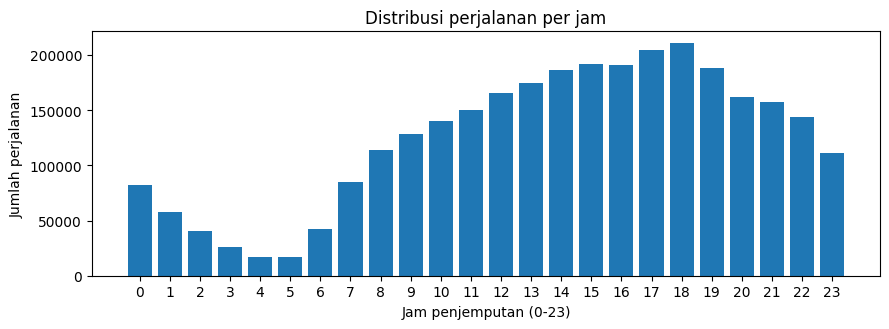

In [45]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

### **Latihan 1**

Pada latihan pertama dilakukan pencarian lima nilai trip_distance terbesar pada DataFrame bersih. Fungsi nlargest(5, "trip_distance") digunakan untuk mengambil lima baris dengan nilai jarak perjalanan paling besar sekaligus menampilkan seluruh kolom pada baris tersebut. Tujuan langkah ini adalah untuk memeriksa apakah perjalanan dengan jarak paling ekstrem masih masuk akal setelah proses pembersihan data dilakukan.

In [46]:
# LATIHAN 1 - 5 trip_distance terbesar

top5_jarak = (
    bersih
    .nlargest(5, "trip_distance")
)

print("=== 5 TRIP_DISTANCE TERBESAR ===")
display(top5_jarak)

=== 5 TRIP_DISTANCE TERBESAR ===


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit,hari,akhir_pekan,tarif_per_menit,jam
1748933,2023-01-19 16:29:36,2023-01-19 18:46:01,1.0,96.70,1,350.000000,50.0,440.750000,136.416667,Thursday,False,3.231,16
526988,2023-01-07 04:29:56,2023-01-07 06:06:16,2.0,93.05,2,542.000000,0.0,564.049988,96.333333,Saturday,True,5.855,4
2402193,2023-01-26 04:55:45,2023-01-26 07:18:50,1.0,92.60,1,262.500000,20.0,312.799988,143.083333,Thursday,False,2.186,4
2902389,2023-01-31 07:04:24,2023-01-31 09:32:54,1.0,92.00,1,334.100006,10.0,368.149994,148.500000,Tuesday,False,2.479,7
927215,2023-01-11 14:23:55,2023-01-11 16:17:58,1.0,90.63,2,250.000000,0.0,272.299988,114.050000,Wednesday,False,2.388,14


### **Latihan 2**

Pada latihan kedua dilakukan pengulangan proses agregasi dengan menggunakan dua ukuran chunksize, yaitu 100.000 baris dan 1.000.000 baris. Kedua percobaan menggunakan fungsi agregasi_bertahap() yang telah dibuat pada J-7 dan fungsi ukur() untuk mencatat waktu proses serta perubahan penggunaan memori (delta_rss_mb). Tujuan perbandingan ini adalah untuk melihat pengaruh ukuran potongan data terhadap waktu pemrosesan dan penggunaan memori.

In [47]:
# LATIHAN 2 - Perbandingan chunksize

hasil_chunk_100k = ukur(
    "agregasi chunking 100k",
    lambda: agregasi_bertahap(CSV, ukuran_chunk=100_000)
)

hasil_chunk_1m = ukur(
    "agregasi chunking 1m",
    lambda: agregasi_bertahap(CSV, ukuran_chunk=1_000_000)
)

print("\n=== HASIL ===")
print(
    "chunksize 100.000:",
    hasil_chunk_100k[0],
    "baris | total:",
    hasil_chunk_100k[1]
)

print(
    "chunksize 1.000.000:",
    hasil_chunk_1m[0],
    "baris | total:",
    hasil_chunk_1m[1]
)

# Ambil catatan performa yang baru saja ditambahkan
perbandingan_chunk = pd.DataFrame(catatan).tail(2)

display(perbandingan_chunk)

[agregasi chunking 100k] 10.76 s | RSS +0.0 MB
[agregasi chunking 1m] 6.34 s | RSS +5.0 MB

=== HASIL ===
chunksize 100.000: 2986911 baris | total: 81621456.74000004
chunksize 1.000.000: 2986911 baris | total: 81621456.73999998


,langkah,detik,delta_rss_mb
6,agregasi chunking 100k,10.76,0.0
7,agregasi chunking 1m,6.34,5.0


### **Latihan 3**

Pada latihan ketiga dibuat kolom baru bernama persen_tip untuk menghitung persentase tip terhadap fare_amount. Perhitungan dilakukan dengan membagi tip_amount dengan fare_amount kemudian dikalikan 100. Untuk menangani kondisi ketika fare_amount bernilai 0, digunakan np.where() sehingga nilai persen_tip untuk kondisi tersebut diisi dengan NaN dan tidak menyebabkan pembagian dengan nol. Setelah itu, data dikelompokkan berdasarkan payment_type untuk menghitung rata-rata persentase tip pada masing-masing metode pembayaran. Selain rata-rata persentase tip, jumlah transaksi dan jumlah fare_amount yang bernilai nol juga ditampilkan sebagai informasi tambahan.

In [48]:
# LATIHAN 3 - Persentase tip per payment_type

import numpy as np

bersih["persen_tip"] = np.where(
    bersih["fare_amount"] != 0,
    (bersih["tip_amount"] / bersih["fare_amount"]) * 100,
    np.nan
)

rata_persen_tip = (
    bersih
    .groupby("payment_type", observed=True)
    .agg(
        rata_persen_tip=("persen_tip", "mean"),
        jumlah_transaksi=("persen_tip", "count"),
        fare_nol=( "fare_amount", lambda x: (x == 0).sum())
    )
    .round(2)
    .reset_index()
)

print("=== RATA-RATA PERSEN TIP PER PAYMENT_TYPE ===")
display(rata_persen_tip)

=== RATA-RATA PERSEN TIP PER PAYMENT_TYPE ===


,payment_type,rata_persen_tip,jumlah_transaksi,fare_nol
0,0,20.219999,64106,0
1,1,25.910000,2385053,11
2,2,0.000000,512885,102
3,3,0.020000,9145,39
4,4,0.150000,15542,28


### **Latihan 4**

Pada latihan keempat dilakukan penyimpanan DataFrame bersih ke dalam format Parquet menggunakan dua jenis kompresi, yaitu Snappy dan Gzip. Proses penulisan masing-masing file diukur menggunakan fungsi ukur() sehingga dapat dibandingkan berdasarkan waktu penulisan dan perubahan penggunaan memori. Setelah file berhasil dibuat, ukuran masing-masing file dihitung dalam satuan MB dan ditampilkan bersama hasil pengukuran performanya.

In [49]:
# LATIHAN 4 - Perbandingan Parquet Snappy vs Gzip

PARQUET_SNAPPY = f"{DIR_SIMPAN}/bersih_snappy.parquet"
PARQUET_GZIP   = f"{DIR_SIMPAN}/bersih_gzip.parquet"

# Snappy
ukur(
    "tulis Parquet snappy",
    lambda: bersih.to_parquet(
        PARQUET_SNAPPY,
        index=False,
        compression="snappy"
    )
)

# Gzip
ukur(
    "tulis Parquet gzip",
    lambda: bersih.to_parquet(
        PARQUET_GZIP,
        index=False,
        compression="gzip"
    )
)

ukuran_snappy = os.path.getsize(PARQUET_SNAPPY) / 1024**2
ukuran_gzip = os.path.getsize(PARQUET_GZIP) / 1024**2

print("=== PERBANDINGAN PARQUET ===")
print(f"Snappy : {ukuran_snappy:.2f} MB")
print(f"Gzip   : {ukuran_gzip:.2f} MB")

hasil_kompresi = (
    pd.DataFrame(catatan)
    .query("langkah in ['tulis Parquet snappy', 'tulis Parquet gzip']")
    .copy()
)

hasil_kompresi["ukuran_mb"] = [
    ukuran_snappy,
    ukuran_gzip
]

display(hasil_kompresi)

[tulis Parquet snappy] 2.61 s | RSS +0.2 MB
[tulis Parquet gzip] 41.80 s | RSS +65.9 MB
=== PERBANDINGAN PARQUET ===
Snappy : 63.31 MB
Gzip   : 50.98 MB


,langkah,detik,delta_rss_mb,ukuran_mb
8,tulis Parquet snappy,2.61,0.2,63.310699
9,tulis Parquet gzip,41.80,65.9,50.976109


### **Latihan 5**

Pada latihan kelima dilakukan persiapan kembali lingkungan PySpark untuk menuliskan ulang agregasi per jam pada J-9 menggunakan Spark SQL. SparkSession dibuat dengan nama aplikasi BD-PS1-Latihan5 dan dijalankan dalam mode local[*], sehingga Spark menggunakan seluruh core yang tersedia pada mesin. Konfigurasi spark.driver.memory ditetapkan sebesar 4 GB dan spark.sql.shuffle.partitions sebanyak 8 partisi. Setelah SparkSession dibuat, level log diatur menjadi WARN agar pesan yang ditampilkan tidak terlalu banyak, kemudian versi Spark diperiksa untuk memastikan lingkungan yang digunakan. Modul memang meminta pada Latihan 5 agar agregasi per jam J-9 ditulis ulang menggunakan Spark SQL dan hasilnya kemudian dibandingkan secara terprogram.

In [50]:
# LATIHAN 5 - Agregasi J-9 dengan Spark SQL

from pyspark.sql import SparkSession, functions as F

spark = (
    SparkSession.builder
    .appName("BD-PS1-Latihan5")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 3.5.1


In [51]:
# Baca data Parquet dan lakukan cleaning yang sama seperti J-8

sdf = spark.read.parquet(PATH)

sdf_bersih = (
    sdf
    .withColumn(
        "durasi_menit",
        (
            F.unix_timestamp(F.col("tpep_dropoff_datetime"))
            - F.unix_timestamp(F.col("tpep_pickup_datetime"))
        ) / 60
    )
    .filter(
        (F.col("trip_distance") > 0) &
        (F.col("trip_distance") < 100)
    )
    .filter(
        (F.col("durasi_menit") >= 1) &
        (F.col("durasi_menit") <= 180)
    )
    .filter(F.col("total_amount") > 0)
)

# Buat temporary view untuk Spark SQL

sdf_bersih.createOrReplaceTempView("trips_bersih")


In [52]:
# Agregasi J-9 ditulis ulang menggunakan Spark SQL

hasil_sql = spark.sql("""
    SELECT
        HOUR(tpep_pickup_datetime) AS jam,
        COUNT(*) AS jumlah_perjalanan,
        ROUND(AVG(trip_distance), 2) AS rata_jarak,
        ROUND(AVG(durasi_menit), 2) AS rata_durasi,
        ROUND(AVG(total_amount), 2) AS rata_tarif,
        ROUND(PERCENTILE_APPROX(total_amount, 0.5), 2) AS median_tarif
    FROM trips_bersih
    GROUP BY HOUR(tpep_pickup_datetime)
    ORDER BY jam
""")


print("\n HASIL SPARK SQL ")
hasil_sql.show(24, truncate=False)

# Ubah hasil Spark SQL menjadi pandas

hasil_sql_pd = hasil_sql.toPandas()



 HASIL SPARK SQL 
+---+-----------------+----------+-----------+----------+------------+
|jam|jumlah_perjalanan|rata_jarak|rata_durasi|rata_tarif|median_tarif|
+---+-----------------+----------+-----------+----------+------------+
|0  |82289            |4.04      |13.57      |28.86     |21.6        |
|1  |57766            |3.53      |12.63      |26.45     |21.2        |
|2  |40445            |3.28      |12.07      |25.06     |20.52       |
|3  |26146            |3.58      |12.15      |26.26     |20.9        |
|4  |16618            |4.79      |13.52      |31.72     |22.7        |
|5  |16940            |6.03      |14.7       |36.75     |22.0        |
|6  |42300            |4.8       |14.49      |30.63     |18.48       |
|7  |84569            |3.69      |14.42      |26.89     |18.48       |
|8  |114064           |3.08      |14.33      |25.21     |19.1        |
|9  |127988           |3.09      |14.23      |25.51     |19.25       |
|10 |140230           |3.13      |14.25      |25.53     |1

In [53]:
# Bandingkan jumlah perjalanan dengan hasil J-9

perbandingan = (
    agregasi[["jam", "jumlah_perjalanan"]]
    .merge(
        hasil_sql_pd[["jam", "jumlah_perjalanan"]],
        on="jam",
        suffixes=("_pandas", "_spark_sql")
    )
)

perbandingan["selisih"] = (
    perbandingan["jumlah_perjalanan_pandas"]
    - perbandingan["jumlah_perjalanan_spark_sql"]
)

print("\n PERBANDINGAN JUMLAH J-9 vs SPARK SQL")
display(perbandingan)


 PERBANDINGAN JUMLAH J-9 vs SPARK SQL


,jam,jumlah_perjalanan_pandas,jumlah_perjalanan_spark_sql,selisih
0,0,82289,82289,0
1,1,57766,57766,0
2,2,40445,40445,0
3,3,26146,26146,0
4,4,16618,16618,0
5,5,16940,16940,0
6,6,42300,42300,0
7,7,84569,84569,0
8,8,114064,114064,0
9,9,127988,127988,0


In [54]:
# Bukti konsistensi secara terprogram

selisih_maksimum = perbandingan["selisih"].abs().max()

print("Selisih maksimum:", selisih_maksimum)

if selisih_maksimum == 0:
    print("Hasil konsisten: jumlah perjalanan per jam sama.")
else:
    print(
        "Terdapat perbedaan hasil. Sumber perbedaan perlu diperiksa."
    )


# Tutup Spark setelah selesai
spark.stop()

Selisih maksimum: 0
Hasil konsisten: jumlah perjalanan per jam sama.
